In [17]:
import pandas as pd
import numpy as np

In [18]:
df = pd.read_csv("GS10-2026-07-MD.csv", skiprows=1, names=["date", "value"], header=0)
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%y")
df["date"] = df["date"].apply(lambda d: d.replace(year=d.year - 100) if d.year >= 2059 else d)
df.sort_values("date").reset_index(drop=True)

series = df["value"].values.astype(np.float32)
dates = df["date"].values

print("Number of observations:", len(series))
print(df.head())

Number of observations: 810
        date  value
0 1959-01-01   4.02
1 1959-02-01   3.96
2 1959-03-01   3.99
3 1959-04-01   4.12
4 1959-05-01   4.31


In [19]:
series_raw = df["value"].values.astype(np.float32)
dates_raw = df["date"].values

series = np.diff(series_raw)
dates = dates_raw[1:]

print("Original length:", len(series_raw))
print("Differenced length:", len(series))

Original length: 810
Differenced length: 809


In [20]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

Mean: 0.00055624236
Median: 0.0
Std: 0.26984555
Min: -1.7599993
Max: 1.6099997
Lag-1 autocorrelation: 0.3037412187110363


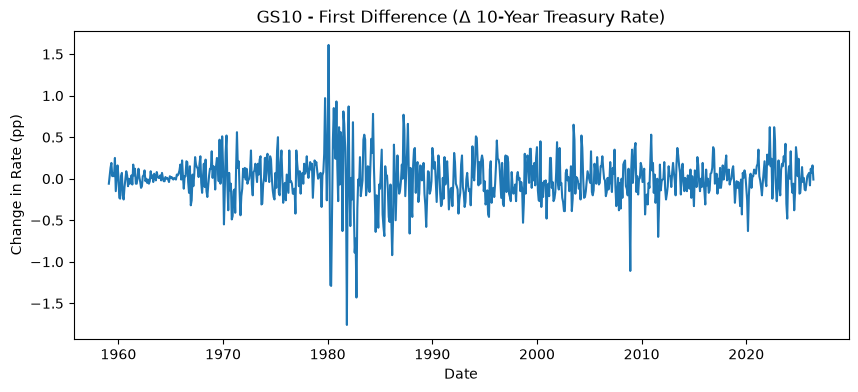

In [21]:
print("Mean:", np.mean(series))
print("Median:", np.median(series))
print("Std:", np.std(series))
print("Min:", np.min(series))
print("Max:", np.max(series))

lag1_autocorr = np.corrcoef(series[:-1], series[1:])[0, 1]
print("Lag-1 autocorrelation:", lag1_autocorr)

plt.figure(figsize=(10,4))
plt.plot(dates, series)
plt.title("GS10 - First Difference (Δ 10-Year Treasury Rate)")
plt.xlabel("Date")
plt.ylabel("Change in Rate (pp)")
plt.show()

In [22]:
def create_windows(series, p):
    """
    series: 1D numpy array
    p: number of lags (window size)
    Returns:
      X: array of shape (num_windows, p)
      y: array of shape (num_windows,)
    """
    X, y = [], []
    for t in range(p, len(series)):
        X.append(series[t-p:t])   # p values before t
        y.append(series[t])       # the value at t
    return np.array(X), np.array(y)

In [23]:
p = 12
X, y = create_windows(series, p)

print("Number of windows:", len(X))
print("X shape:", X.shape, "y shape:", y.shape)

Number of windows: 797
X shape: (797, 12) y shape: (797,)


In [24]:
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)   # (N, p, 1) for N windows of p length with 1 feature
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)   # (N, 1)
    return X_t, y_t

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t, y_val_t = to_tensor(X_val, y_val)
X_test_t, y_test_t = to_tensor(X_test, y_test)

print("Train:", X_train_t.shape, "Val:", X_val_t.shape, "Test:", X_test_t.shape)

Train: torch.Size([557, 12, 1]) Val: torch.Size([120, 12, 1]) Test: torch.Size([120, 12, 1])


In [25]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

In [26]:
class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(num_features))
        self.affine_bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode):
        if mode == "norm":
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.std = x.std(dim=1, keepdim=True, unbiased=False).detach() + self.eps #unbiased here is a potential design decision
            x = (x - self.mean) / self.std
            x = x * self.affine_weight + self.affine_bias
            return x
        elif mode == "denorm":
            x = (x - self.affine_bias) / self.affine_weight
            x = x * self.std + self.mean
            return x
        raise ValueError("mode must be 'norm' or 'denorm'")

In [27]:
class FullyConnectedNN(nn.Module):
    def __init__(self, p, n_hidden=20):
        super().__init__()
        self.revin = RevIN(num_features=1)
        self.hidden = nn.Linear(p, n_hidden)
        self.act = nn.ReLU()
        self.output = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x_norm = self.revin(x, mode="norm")
        x_flat = x_norm.squeeze(-1)
        h = self.act(self.hidden(x_flat))
        pred_norm = self.output(h).unsqueeze(1)
        pred = self.revin(pred_norm, mode="denorm")
        return pred.squeeze(1)

In [28]:
model = FullyConnectedNN(p=p, n_hidden=20)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #design choices

train_losses, val_losses = [], []

for epoch in range(500):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val_t), y_val_t).item()
    val_losses.append(val_loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 0, Train Loss: 0.1023, Val Loss: 0.0520
Epoch 100, Train Loss: 0.0578, Val Loss: 0.0603
Epoch 200, Train Loss: 0.0499, Val Loss: 0.0664
Epoch 300, Train Loss: 0.0451, Val Loss: 0.0669
Epoch 400, Train Loss: 0.0423, Val Loss: 0.0708


In [29]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t)
    test_loss = loss_fn(test_pred, y_test_t)
print(f"Test MSE: {test_loss.item():.4f}")

Test MSE: 0.0540


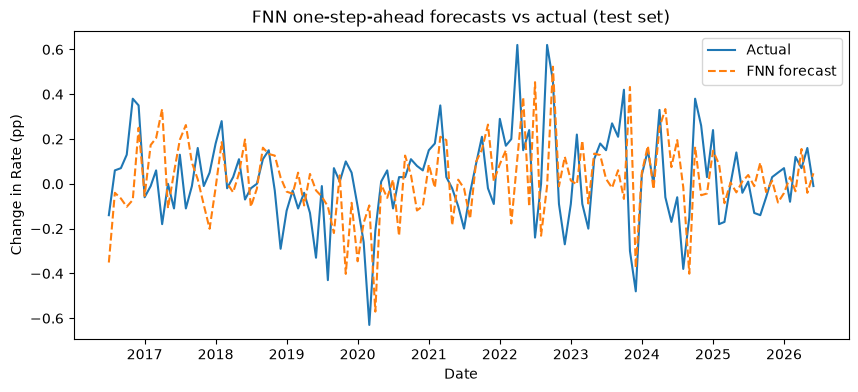

In [30]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t).squeeze(-1).numpy()

test_dates = dates[p + val_end:]

plt.figure(figsize=(10,4))
plt.plot(test_dates, y_test, label="Actual")
plt.plot(test_dates, test_pred, label="FNN forecast", linestyle="--")
plt.title("FNN one-step-ahead forecasts vs actual (test set)")
plt.xlabel("Date")
plt.ylabel("Change in Rate (pp)")
plt.legend()
plt.show()